In [3]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
#import keras
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
#from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings("ignore")

In [4]:
#Import the dataset
df = pd.read_csv('fraud_detection.csv')

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [7]:
print('Number of Transactions and rows:',df.shape)

Number of Transactions and rows: (6362620, 11)


In [8]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [9]:
#Check for duplicate transactions
df.duplicated().sum()

np.int64(0)

In [10]:
#Check for missing columns
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

EXPLORATORY DATA ANALYSIS (EDA)

In [11]:
#Percentage of fraud vs non-fraud
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

<Axes: xlabel='isFraud'>

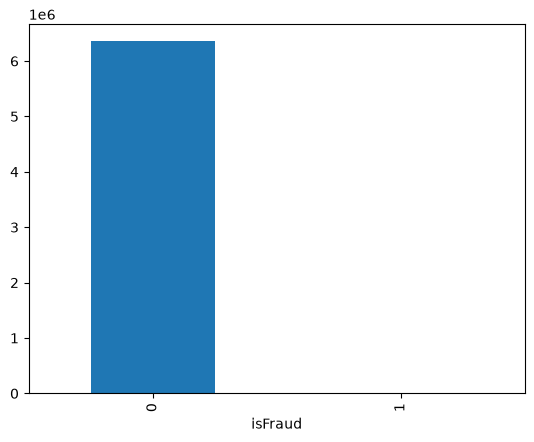

In [12]:
#Visualizing Target(isFraud)
df['isFraud'].value_counts().plot(kind='bar')

In [13]:
#Count of traction types
df['type'].value_counts().sort_values(ascending=False)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

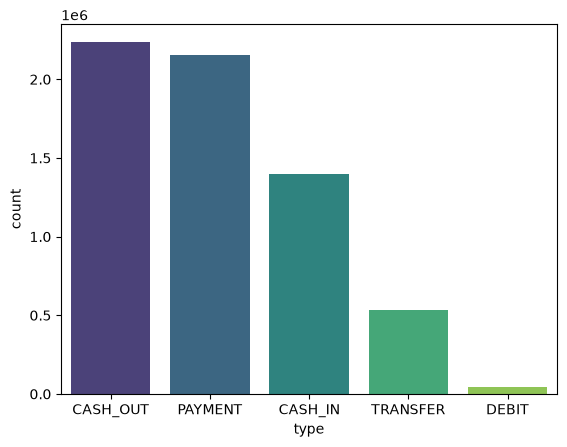

In [14]:
#Count of transactions visualization
sns.countplot(data=df,x='type',palette='viridis',order=df["type"].value_counts().index)

<Axes: xlabel='type', ylabel='count'>

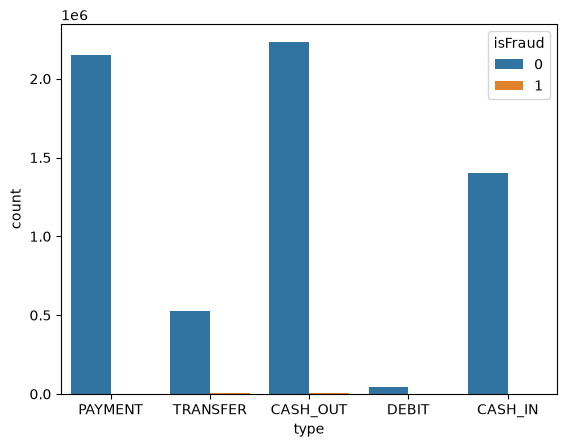

In [15]:
#Transactions of 'type' 
sns.countplot(data=df,x='type',hue='isFraud')

In [16]:
#Checking correlation in relation to isFraud
df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

**DATA PRE-PROCESSING**

In [17]:
#Get the transaction type
df['transaction_type'] = df['nameOrig'].str[0] + df['nameDest'].str[0]

In [18]:
#Get the net sender and receiver balance
df['net_sender'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['net_receiver'] = df['newbalanceDest'] - df['oldbalanceDest']

In [20]:
#Drop the columns that are no longer needed
df = df.drop(columns=['nameOrig','nameDest','isFlaggedFraud', 'oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'])

In [21]:
df.head()

,step,type,amount,isFraud,transaction_type,net_sender,net_receiver
0,1,PAYMENT,9839.64,0,CM,9839.64,0.0
1,1,PAYMENT,1864.28,0,CM,1864.28,0.0
2,1,TRANSFER,181.00,1,CC,181.00,0.0
3,1,CASH_OUT,181.00,1,CC,181.00,-21182.0
4,1,PAYMENT,11668.14,0,CM,11668.14,0.0


In [23]:
#Splitting into training and target
X_full = df.drop(columns=['isFraud']) #Features
y_full = df['isFraud'] #Target

In [24]:
#Using 10% of the original dataset
X_sample, _, y_sample, _ = train_test_split(X_full, y_full, train_size=0.1, stratify=y_full, random_state=30)

In [25]:
#Create a single dataframe from the sample
sampled_df = X_sample.copy()
sampled_df['isFraud'] = y_sample

In [26]:
#Percentage of fraud vs non-fraud
sampled_df['isFraud'].value_counts(normalize=True)

isFraud
0    0.99871
1    0.00129
Name: proportion, dtype: float64

In [27]:
sampled_df.head()

,step,type,amount,transaction_type,net_sender,net_receiver,isFraud
4924590,350,CASH_OUT,63144.80,CC,416.00,63144.80,0
3346912,253,CASH_IN,104563.72,CC,-104563.72,-104563.72,0
5704625,398,CASH_IN,190292.76,CC,-190292.75,-190292.75,0
6295200,670,CASH_IN,45307.82,CC,-45307.82,-45307.83,0
2491511,204,CASH_IN,133395.11,CC,-133395.11,-133395.11,0


In [28]:
#Splitting into training and target
X = sampled_df.drop('isFraud', axis=1) #Features
y = sampled_df['isFraud'] #Target

In [29]:
#Split into training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=30)

In [30]:
#Categorical columns
cat_columns = list(X.select_dtypes(['object', 'category']).columns)

In [31]:
#Numeric columns
num_columns = list(X.select_dtypes(['int64', 'float64']).columns)

In [32]:
#Categorical column pipeline
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown="ignore"))
])

In [33]:
#Numeric column pipeline
num_pipeline = Pipeline([
    ('ss', StandardScaler())
])

In [34]:
preprocessor = ColumnTransformer(transformers=[("num", num_pipeline, num_columns),
                                               ("cat", cat_pipeline, cat_columns)])

In [35]:
#Applying cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)

**MODELING**

In [36]:
#Logistic Regression pipeline
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE()),
    ('lr', LogisticRegression())
])

In [37]:
#Logistic Regression Parameters
params_lr = {
    'lr__C': [0.1, 1.0, 10.0],  
    'lr__penalty': ['l1', 'l2'], 
    'lr__solver': ['liblinear'] 
}

In [38]:
#Logistic Regression Hyper-parameter tuning
model_lr = GridSearchCV(
    pipeline_lr,
    param_grid = params_lr,
    cv = cv,
    n_jobs = 5, 
    verbose = 1
)

In [39]:
#Training the Logistic Regression model
model_lr.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.1, 1.0, ...], 'lr__penalty': ['l1', 'l2'], 'lr__solver': ['liblinear']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_se

In [40]:
model_lr.score(X_train, y_train)

0.9479655566011603

In [41]:
y_pred_lr = model_lr.predict(X_test)

In [42]:
#Logistic Regression classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    127089
           1       0.02      0.96      0.04       164

    accuracy                           0.95    127253
   macro avg       0.51      0.95      0.51    127253
weighted avg       1.00      0.95      0.97    127253



In [43]:
#Logistic Regression confusion matrix
print(confusion_matrix(y_test, y_pred_lr))

[[120428   6661]
 [     7    157]]


In [44]:
#Best Logistic Regression model
best_lr_model = model_lr.best_estimator_
preprocessor_transformer_lr = best_lr_model.named_steps['preprocessor']

In [45]:
lr_estimator = best_lr_model.named_steps['lr']
importances_lr = lr_estimator.coef_[0]
transformed_feature_names_lr = preprocessor_transformer_lr.get_feature_names_out()
feat_importance_lr = pd.Series(importances_lr, index=transformed_feature_names_lr).sort_values()

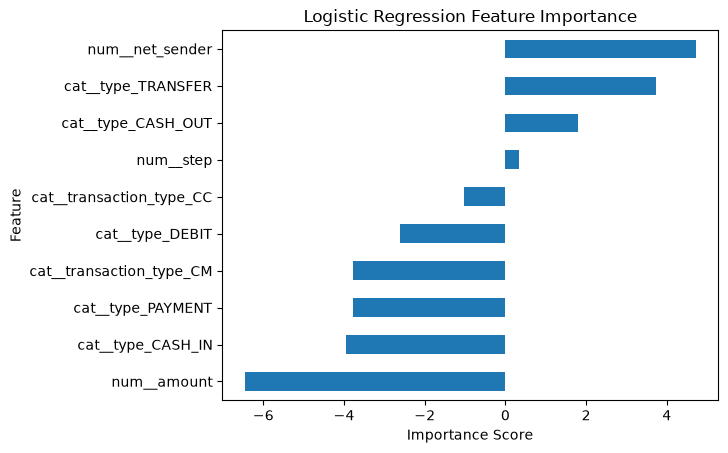

In [46]:
#Plotting the Logistic Regression feature importance
feat_importance_lr.tail(10).plot(kind='barh')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance")
plt.show()

In [47]:
#Random Forest Classifier pipeline
pipeline_rfc = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE()),
    ('rfc', RandomForestClassifier())
])

In [48]:
params = {
    'rfc__n_estimators': range(10, 100, 10),
    'rfc__max_depth': range(10, 50, 10)
}

In [49]:
#Random Forest Classifier Hyper-parameter tuning
model_rfc = GridSearchCV(
    pipeline_rfc,
    param_grid = params,
    cv = cv,
    n_jobs = 5, 
    verbose = 1
)

In [50]:
#Training the Random Forest Classifier
model_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rfc__max_depth': range(10, 50, 10), 'rfc__n_estimators': range(10, 100, 10)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selectio

In [51]:
model_rfc.score(X_train, y_train)

0.9995442123813135

In [52]:
y_pred_rfc = model_rfc.predict(X_test)

In [53]:
#Random Forest classification report
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    127089
           1       0.13      0.87      0.22       164

    accuracy                           0.99    127253
   macro avg       0.56      0.93      0.61    127253
weighted avg       1.00      0.99      1.00    127253



In [54]:
#Random forest confusion matrix
print(confusion_matrix(y_test, y_pred_rfc))

[[126107    982]
 [    21    143]]


In [55]:
#Best Random forest classier
best_rfc_model = model_rfc.best_estimator_
preprocessor_transformer_rfc = best_rfc_model.named_steps['preprocessor']

In [56]:
rfc_estimator = best_rfc_model.named_steps['rfc']
importances_rfc = rfc_estimator.feature_importances_
transformed_feature_names_rfc = preprocessor_transformer_rfc.get_feature_names_out()
feat_importance_rfc = pd.Series(importances_rfc, index=transformed_feature_names_rfc).sort_values()

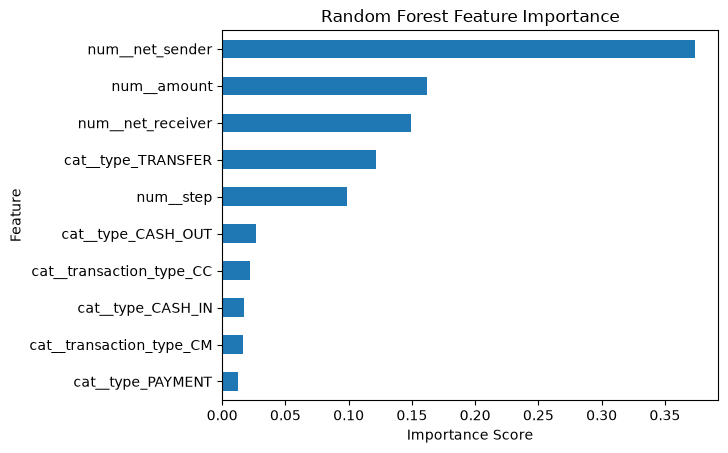

In [57]:
#Plotting the random forst classifier feature importance
feat_importance_rfc.tail(10).plot(kind='barh')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()

In [58]:
# XGB Classifier Model Pipeline
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ('smote', SMOTE(random_state=30)),
    ("xgb", XGBClassifier(random_state=30))
])

In [59]:
# XGB Classifier Model Hperparamters
params_xgb = {
    'xgb__max_depth': [10, 50, 10],
    'xgb__n_estimators': [10, 25, 5],
    'xgb__learning_rate': [0.1],
    'xgb__tree_method': ['hist'],
    'xgb__n_jobs': [-1]
}

In [60]:
# XGB Classifier Hyperparameter tuning
model_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid=params_xgb,
    cv=cv,
    n_jobs=5,
    verbose=1
)

In [61]:
# Training the XGB Classifier model
model_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__learning_rate': [0.1], 'xgb__max_depth': [10, 50, ...], 'xgb__n_estimators': [10, 25, ...], 'xgb__n_jobs': [-1], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation

In [62]:
model_xgb.score(X_train, y_train)

0.993668088383506

In [63]:
y_pred_xgb = model_xgb.predict(X_test)

In [64]:
# XGB Classifier model classification report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    127089
           1       0.12      0.86      0.21       164

    accuracy                           0.99    127253
   macro avg       0.56      0.93      0.60    127253
weighted avg       1.00      0.99      0.99    127253



In [65]:
# XGB Classifier model confusion matrix
print(confusion_matrix(y_test, y_pred_xgb))

[[126039   1050]
 [    23    141]]


In [66]:
# Best XGB Classier
best_xgb_model = model_xgb.best_estimator_
preprocessor_transformer_xgb = best_xgb_model.named_steps['preprocessor']

In [67]:
xgb_estimator = best_xgb_model.named_steps['xgb']
importances_xgb = xgb_estimator.feature_importances_
transformed_feature_names_xgb = preprocessor_transformer_xgb.get_feature_names_out()
feat_importance_xgb = pd.Series(importances_xgb, index=transformed_feature_names_xgb).sort_values()

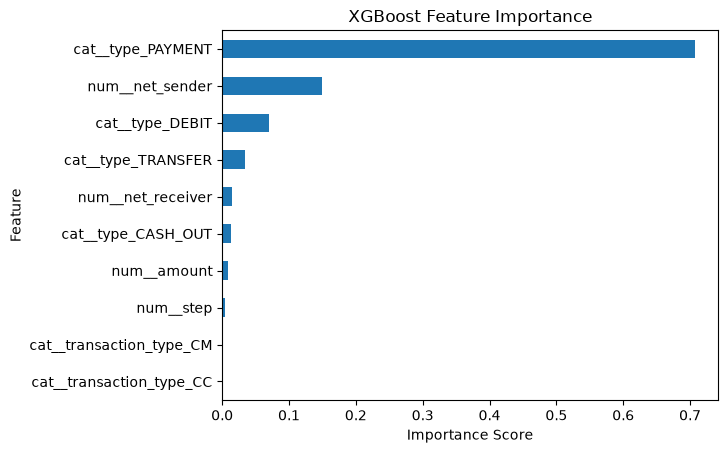

In [68]:
#Plotting the XGB Classifier feature importance
feat_importance_xgb.tail(10).plot(kind='barh')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()

In [69]:
#Decision Tree Classifier Model Pipeline
pipeline_dtc = Pipeline([
    ("preprocessor", preprocessor),
    ('smote', SMOTE(random_state=30)),
    ("dtc", DecisionTreeClassifier(random_state=30))
])

In [70]:
#Decision Tree Classifier hyper-parameters
params_dtc = param_grid = {
    'dtc__max_depth': [3, 5, 7],   
    'dtc__min_samples_split': [2, 5, 10], 
    'dtc__min_samples_leaf': [1, 2, 4]   
} 

In [71]:
#Decision Tree Classifier Hyperparameter tuning
model_dtc = GridSearchCV(
    pipeline_dtc,
    param_grid=params_dtc,
    cv=cv,
    n_jobs=5,
    verbose=1
)

In [72]:
#Training the Decision Tree model
model_dtc.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=30))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dtc__max_depth': [3, 5, ...], 'dtc__min_samples_leaf': [1, 2, ...], 'dtc__min_samples_split': [2, 5, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_gl

In [73]:
model_dtc.score(X_train, y_train)

0.9569319992377345

In [74]:
y_pred_dtc = model_dtc.predict(X_test)

In [75]:
#Decision Tree model classification report
print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    127089
           1       0.03      0.95      0.05       164

    accuracy                           0.96    127253
   macro avg       0.51      0.95      0.51    127253
weighted avg       1.00      0.96      0.98    127253



In [76]:
#Decision Tree model confusion matrix
print(confusion_matrix(y_test, y_pred_dtc))

[[121469   5620]
 [     9    155]]


In [77]:
#Best Decision Tree model
best_dtc_model = model_dtc.best_estimator_
preprocessor_transformer_dtc = best_dtc_model.named_steps['preprocessor']

In [78]:
dtc_estimator = best_dtc_model.named_steps['dtc']
importances_dtc = dtc_estimator.feature_importances_
transformed_feature_names_dtc = preprocessor_transformer_dtc.get_feature_names_out()
feat_importance_dtc = pd.Series(importances_dtc, index=transformed_feature_names_dtc).sort_values()

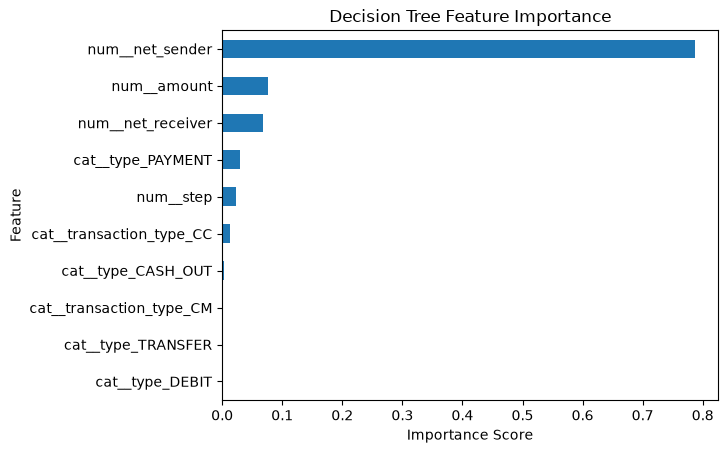

In [79]:
#Plotting the Decision Tree Classifier feature importance
feat_importance_dtc.tail(10).plot(kind='barh')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.show()

In [80]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [81]:
import joblib

In [83]:
joblib.dump(best_xgb_model, 'fraud_xgb_model.joblib')

['fraud_xgb_model.joblib']

In [84]:
joblib.dump(best_rfc_model, 'fraud_rfc_model.joblib')

['fraud_rfc_model.joblib']

In [92]:
#Building the Neural Network
model = keras.Sequential([
    keras.layers.Input(X_train_processed.shape[1],),
    keras.layers.Dense(units=100, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(units=80, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=60, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(units=40, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units=20, kernel_initializer='he_uniform', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(units=1, kernel_initializer='he_uniform', activation='sigmoid', kernel_regularizer=regularizers.l2(0.001))
])

2025-08-27 23:25:22.956185: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [93]:
#Introducing early stopping
early_stopping = keras.callbacks.EarlyStopping(
    min_delta = 0.001,
    patience = 20,
    restore_best_weights=True
)

In [97]:
#Compile the Neural Network
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])

In [98]:
#Training the Neural Network
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_test_processed, y_test),
    batch_size=512,
    epochs=10, 
    verbose=1 
)

Epoch 1/10
995/995 [==============================] - 7s 5ms/step - loss: 0.3377 - accuracy: 0.9779 - precision: 0.0211 - recall: 0.3546 - val_loss: 0.0529 - val_accuracy: 0.9989 - val_precision: 1.0000 - val_recall: 0.1280
Epoch 2/10
995/995 [==============================] - 5s 5ms/step - loss: 0.0265 - accuracy: 0.9991 - precision: 0.8375 - recall: 0.3607 - val_loss: 0.0162 - val_accuracy: 0.9991 - val_precision: 1.0000 - val_recall: 0.2805
Epoch 3/10
995/995 [==============================] - 5s 5ms/step - loss: 0.0136 - accuracy: 0.9991 - precision: 0.8543 - recall: 0.3927 - val_loss: 0.0122 - val_accuracy: 0.9991 - val_precision: 1.0000 - val_recall: 0.3232
Epoch 4/10
995/995 [==============================] - 4s 4ms/step - loss: 0.0108 - accuracy: 0.9991 - precision: 0.8733 - recall: 0.3988 - val_loss: 0.0108 - val_accuracy: 0.9990 - val_precision: 0.9737 - val_recall: 0.2256
Epoch 5/10
995/995 [==============================] - 4s 4ms/step - loss: 0.0089 - accuracy: 0.9992 - pr

In [99]:
loss, acc, precision, recall = model.evaluate(X_test_processed, y_test)

3977/3977 [==============================] - 5s 1ms/step - loss: 0.0058 - accuracy: 0.9992 - precision: 0.9848 - recall: 0.3963      


In [100]:
#Sampled_df is already sorted 
split_point = len(sampled_df) // 2
old_data = sampled_df.iloc[:split_point].copy()
new_data = sampled_df.iloc[split_point:].copy()

# Create features (X) and target (y) for both datasets
X_old = old_data.drop('isFraud', axis=1)
y_old = old_data['isFraud']

X_new = new_data.drop('isFraud', axis=1)
y_new = new_data['isFraud']

In [105]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(random_state=30))
])

In [106]:
# Train the pipeline on your OLD data
xgb_pipeline.fit(X_old, y_old)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('ss',
                                                                   StandardScaler())]),
                                                  ['step', 'amount',
                                                   'net_sender',
                                                   'net_receiver']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['type',
                                                   'transaction_type'])])),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=Non...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [107]:
# Evaluate the same pipeline on the new data (this proves drift)
preds_new = xgb_pipeline.predict(X_new)
print("Performance of 'Old' Pipeline on NEW Data:")
print("F1-Score:", f1_score(y_new, preds_new))
print("Recall:", recall_score(y_new, preds_new))

Performance of 'Old' Pipeline on NEW Data:
F1-Score: 0.7478005865102639
Recall: 0.6505102040816326


In [108]:
#New pipeline to train it on the new data
xgb_pipeline_retrained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=30))
])

In [109]:
#Training the new XGB model
xgb_pipeline_retrained.fit(X_new, y_new)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('ss',
                                                                   StandardScaler())]),
                                                  ['step', 'amount',
                                                   'net_sender',
                                                   'net_receiver']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['type',
                                                   'transaction_type'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_byle...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [110]:
#Evaluate the retrained pipeline on the new data
preds_retrained = xgb_pipeline_retrained.predict(X_new)
print("\nPerformance of RETRAINED Pipeline on NEW Data:")
print("F1-Score:", f1_score(y_new, preds_retrained))
print("Recall:", recall_score(y_new, preds_retrained))


Performance of RETRAINED Pipeline on NEW Data:
F1-Score: 0.8778409090909091
Recall: 0.7882653061224489
